In [1]:
import cv2 as cv
import glob
import os
from matplotlib import pyplot as plt

In [2]:
image_folder = '/home/filelele/Pictures/floor1_normal/orig_frames/'
image_paths = sorted(glob.glob(os.path.join(image_folder, '*.jpg')))


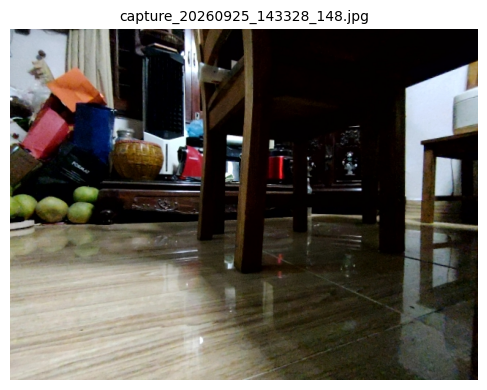

In [3]:
import random
from PIL import Image

n_samples = 1
sample_paths = random.sample(list(image_paths), min(n_samples, len(image_paths)))
fig, axes = plt.subplots(1, len(sample_paths), figsize=(6 * len(sample_paths), 4*len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for ax, path in zip(axes, sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(str(path).split('/')[-1], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()


### ==> Luminance noise +Chroma noise

### General Non-local means denoising

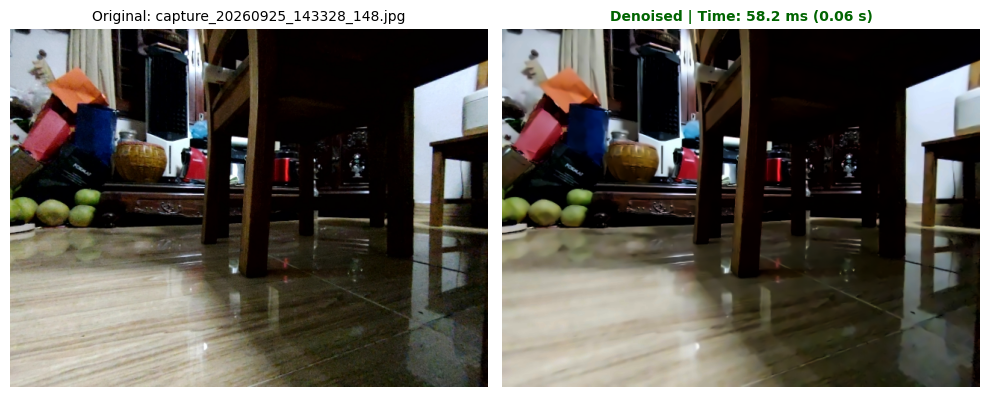

In [7]:
import time

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for i, path in enumerate(sample_paths):
    img_bgr = cv.imread(str(path))
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Measure denoising time
    start_time = time.perf_counter()
    denoised_rgb = cv.fastNlMeansDenoisingColored(
        img_rgb, 
        None, 
        h=10, 
        hColor=10, 
        templateWindowSize=5, 
        searchWindowSize=9
    )
    elapsed_ms = (time.perf_counter() - start_time) * 1000

    # Plot Original
    axes[i][0].imshow(img_rgb)
    axes[i][0].set_title(f"Original: {str(path).split('/')[-1]}", fontsize=10)
    axes[i][0].axis('off')

    # Plot Denoised with elapsed time
    axes[i][1].imshow(denoised_rgb)
    axes[i][1].set_title(f"Denoised | Time: {elapsed_ms:.1f} ms ({elapsed_ms/1000:.2f} s)", fontsize=10, color='darkgreen', fontweight='bold')
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()


### ==> Destroy important edge

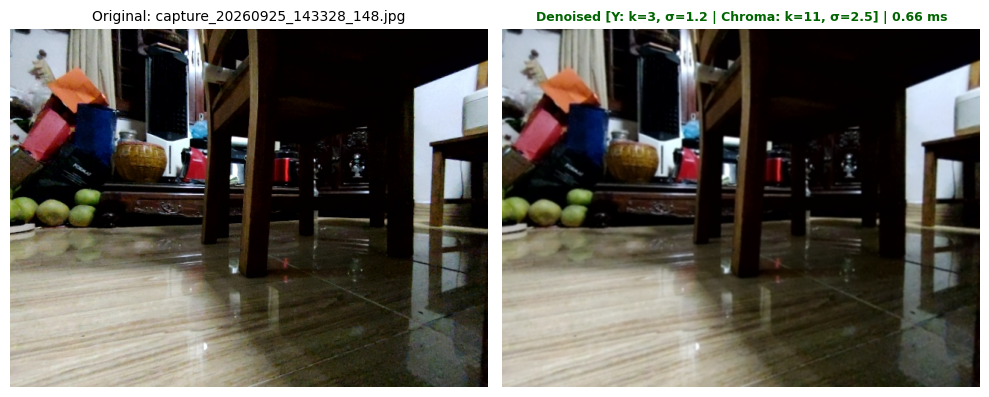

In [8]:
# Filter parameters for Chroma (Cr, Cb) - usually larger to kill color splotches
ksize_chroma = (11, 11)   # Must be odd numbers
sigma_chroma = 2.5

# Filter parameters for Luminance (Y) - usually smaller to preserve edge sharpness
ksize_luma = (3, 3)       # Must be odd numbers, e.g. (3, 3) or (5, 5)
sigma_luma = 1.2         # Set to 0 to auto-compute from kernel size

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for i, path in enumerate(sample_paths):
    img_bgr = cv.imread(str(path))
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    start_time = time.perf_counter()

    # Convert to YCrCb (Y = Luma, Cr/Cb = Chroma)
    ycrcb = cv.cvtColor(img_rgb, cv.COLOR_RGB2YCrCb)
    y, cr, cb = cv.split(ycrcb)

    # Gaussian blur on Luminance channel (Y)
    y_blur = cv.GaussianBlur(y, ksize_luma, sigma_luma)

    # Gaussian blur on Chroma channels (Cr, Cb)
    cr_blur = cv.GaussianBlur(cr, ksize_chroma, sigma_chroma)
    cb_blur = cv.GaussianBlur(cb, ksize_chroma, sigma_chroma)

    ycrcb_filtered = cv.merge([y_blur, cr_blur, cb_blur])
    denoised_rgb = cv.cvtColor(ycrcb_filtered, cv.COLOR_YCrCb2RGB)

    elapsed_ms = (time.perf_counter() - start_time) * 1000

    axes[i][0].imshow(img_rgb)
    axes[i][0].set_title(f"Original: {str(path).split('/')[-1]}", fontsize=10)
    axes[i][0].axis('off')

    axes[i][1].imshow(denoised_rgb)
    axes[i][1].set_title(
        f"Denoised [Y: k={ksize_luma[0]}, σ={sigma_luma} | Chroma: k={ksize_chroma[0]}, σ={sigma_chroma}] | {elapsed_ms:.2f} ms",
        fontsize=9, color='darkgreen', fontweight='bold'
    )
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()


### ==> Nearly the same?

In [3]:
from tqdm import tqdm

# Output directory: ../denoised_frames relative to image_folder
output_folder = os.path.normpath(os.path.join(image_folder, '../denoised_frames'))
os.makedirs(output_folder, exist_ok=True)

ksize_chroma = (11, 11)
sigma_chroma = 2.5

ksize_luma = (3, 3)
sigma_luma = 1.2

print(f"Processing {len(image_paths)} images...")
print(f"Saving to: {output_folder}")
i = 0
subsample_interval = 1
for path in tqdm(image_paths, desc="Denoising frames"):
    if i % subsample_interval != 0:
        i += 1
        continue
    img_bgr = cv.imread(path)
    if img_bgr is None:
        continue

    ycrcb = cv.cvtColor(img_bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)

    y_blur = cv.GaussianBlur(y, ksize_luma, sigma_luma)
    cr_blur = cv.GaussianBlur(cr, ksize_chroma, sigma_chroma)
    cb_blur = cv.GaussianBlur(cb, ksize_chroma, sigma_chroma)

    ycrcb_filtered = cv.merge([y_blur, cr_blur, cb_blur])
    denoised_bgr = cv.cvtColor(ycrcb_filtered, cv.COLOR_YCrCb2BGR)

    filename = os.path.basename(path)
    save_path = os.path.join(output_folder, filename)
    cv.imwrite(save_path, denoised_bgr)
    i+=1
print("Done! All frames saved successfully.")


Processing 77 images...
Saving to: /home/filelele/Pictures/floor1_normal/denoised_frames


Denoising frames:   0%|          | 0/77 [00:00<?, ?it/s]

Denoising frames: 100%|██████████| 77/77 [00:00<00:00, 245.16it/s]

Done! All frames saved successfully.
